In [1]:
pip install pandas matplotlib numpy scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 25.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 28.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


1a  PHASE 1a — Power Rankings + Win Probabilities

Rank all 32 teams, then predict 16 matchup outcomes using logistic regression


In [2]:
# ============================================================
# PHASE 1a — STEP 1: League Table
# ============================================================
import pandas as pd
import numpy as np

df = pd.read_excel('whl_2025.xlsx')

# Aggregate to one row per game
games = df.groupby('game_id').agg(
    home_team        = ('home_team',              'first'),
    away_team        = ('away_team',              'first'),
    went_ot          = ('went_ot',                'first'),
    home_goals       = ('home_goals',             'sum'),
    away_goals       = ('away_goals',             'sum'),
    home_xg          = ('home_xg',                'sum'),
    away_xg          = ('away_xg',                'sum'),
    home_shots       = ('home_shots',             'sum'),
    away_shots       = ('away_shots',             'sum'),
    home_penalties   = ('home_penalties_committed','sum'),
    away_penalties   = ('away_penalties_committed','sum'),
).reset_index()

games['home_win'] = (games['home_goals'] > games['away_goals']).astype(int)
games['ot_game']  = games['went_ot'] == 1

# Build per-team season stats
teams   = df['home_team'].unique()
records = []

for team in teams:
    hg = games[games['home_team'] == team]
    ag = games[games['away_team'] == team]
    n  = len(hg) + len(ag)

    wins      = hg['home_win'].sum() + (~ag['home_win'].astype(bool)).sum()
    h_otl     = ((~hg['home_win'].astype(bool)) & hg['ot_game']).sum()
    a_otl     = (ag['home_win'].astype(bool) & ag['ot_game']).sum()
    ot_losses = h_otl + a_otl
    losses    = (n - wins) - ot_losses
    points    = wins * 2 + ot_losses * 1

    xgf = hg['home_xg'].sum() + ag['away_xg'].sum()
    xga = hg['away_xg'].sum() + ag['home_xg'].sum()

    records.append({'team': team, 'GP': n, 'W': int(wins),
        'L': int(losses), 'OTL': int(ot_losses), 'PTS': int(points),
        'xGF_pg': round(xgf/n, 3), 'xGA_pg': round(xga/n, 3)})

league_table = (pd.DataFrame(records)
    .sort_values('PTS', ascending=False)
    .reset_index(drop=True))

# Composite power score (used as feature in logistic regression below)
def normalize(s, higher_better=True):
    n = (s - s.min()) / (s.max() - s.min())
    return n if higher_better else 1 - n

league_table['power_score'] = (
    normalize(league_table['PTS'])              * 0.40 +
    normalize(league_table['xGF_pg'])           * 0.35 +
    normalize(league_table['xGA_pg'], False)    * 0.25
)
league_table['power_rank'] = (
    league_table['power_score'].rank(ascending=False).astype(int))
league_table = league_table.sort_values('power_rank').reset_index(drop=True)

print('POWER RANKINGS:')
print(league_table[['power_rank','team','PTS','xGF_pg','xGA_pg']].to_string())
league_table.to_csv('power_rankings.csv', index=False)


POWER RANKINGS:
    power_rank          team  PTS  xGF_pg  xGA_pg
0            1        brazil  122   3.323   2.705
1            2      thailand  107   3.594   2.703
2            3      pakistan  106   3.472   2.847
3            4   netherlands  114   2.957   2.461
4            5          peru  112   2.982   2.621
5            6         china  101   3.121   2.695
6            7        panama  101   3.140   2.944
7            8            uk   91   3.370   2.927
8            9         india  104   2.919   2.902
9           10        mexico   87   3.219   2.717
10          11     guatemala   92   3.118   2.839
11          12        france   85   3.252   2.855
12          13        serbia   88   3.382   3.222
13          14       iceland  101   2.806   3.033
14          15   south_korea   86   3.169   3.063
15          16      ethiopia   98   2.920   3.204
16          17   philippines   99   2.605   2.880
17          18       morocco   85   3.043   2.971
18          19   new_zealand   86 

In [3]:
# ============================================================
# PHASE 1a — STEP 2: Logistic Regression Win Probabilities
#
# What is logistic regression?
# It learns a curve that maps numeric inputs to a probability
# between 0 and 1. We train it on real season game data so it
# learns what actually predicts wins — not just our assumption.
#
# Features we use:
#   xg_diff    = home xG minus away xG in-game (performance gap)
#   str_diff   = home team season strength minus away strength
#   home_adv   = constant 1 (model learns the home advantage weight)
# ============================================================
from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Build a team strength lookup from the league table
strength = league_table.set_index('team')['power_score'].to_dict()

# Add features to the games dataframe
games['home_str']  = games['home_team'].map(strength)
games['away_str']  = games['away_team'].map(strength)
games['str_diff']  = games['home_str'] - games['away_str']
games['xg_diff']   = games['home_xg']  - games['away_xg']
games['home_adv']  = 1  # constant — model learns home advantage

# Train the model on the full season
features = ['xg_diff', 'str_diff', 'home_adv']
X = games[features].values
y = games['home_win'].values

scaler  = StandardScaler()          # normalize so features are comparable
X_sc    = scaler.fit_transform(X)

model   = LogisticRegression(random_state=42)
model.fit(X_sc, y)

# Cross-validated accuracy (5-fold) — tells us how good the model is
cv_acc  = cross_val_score(model, X_sc, y, cv=5, scoring='accuracy').mean()
print(f'Model cross-validated accuracy: {cv_acc:.1%}')  # ~62%

# ── Predict the 16 tournament matchups ───────────────────────────
matchups = pd.read_excel('WHSDSC_Rnd1_matchups.xlsx')

results = []
for _, row in matchups.iterrows():
    h, a = row['home_team'], row['away_team']

    # For tournament games we don't have in-game xg_diff yet,
    # so we set it to 0 (neutral) and let team strength do the work
    X_pred = scaler.transform([[0,
                                strength.get(h,0.5) - strength.get(a,0.5),
                                1]])
    prob   = model.predict_proba(X_pred)[0][1]   # P(home wins)

    results.append({'game':          row['game'],
                    'home_team':     h,
                    'away_team':     a,
                    'home_win_prob': round(prob, 3)})

win_probs = pd.DataFrame(results)
print('\nWIN PROBABILITIES (submit these 16 values):')
print(win_probs.to_string())
win_probs.to_csv('win_probabilities.csv', index=False)


Model cross-validated accuracy: 63.6%

WIN PROBABILITIES (submit these 16 values):
    game    home_team     away_team  home_win_prob
0      1       brazil    kazakhstan          0.679
1      2  netherlands      mongolia          0.690
2      3         peru        rwanda          0.649
3      4     thailand          oman          0.657
4      5     pakistan       germany          0.629
5      6        india           usa          0.597
6      7       panama   switzerland          0.608
7      8      iceland        canada          0.550
8      9        china        france          0.564
9     10  philippines       morocco          0.537
10    11     ethiopia  saudi_arabia          0.556
11    12    singapore   new_zealand          0.526
12    13    guatemala   south_korea          0.555
13    14           uk        mexico          0.543
14    15      vietnam        serbia          0.496
15    16    indonesia           uae          0.546


PHASE 1a DELIVERABLES READY  

Submit: (1) The 32-team ranked list from power_rankings.csv — use the power_rank column. (2) The 16 home_win_prob values from win_probabilities.csv. All values are already between 0 and 1 (the logistic regression guarantees this).

PHASE 1b — Offensive Line Disparity with Confounding Controls

Rank the top 10 teams — accounting for TOI and opponent quality confounders


WHAT IS CONFOUNDING? (And why it matters here)

A confounder is a hidden variable that distorts your measurement. In this dataset, two confounders would bias your line disparity results if not controlled:

Time on Ice (TOI) — A line that plays longer shifts naturally generates more raw xG. If you compare raw xG totals, the first line looks better just because it plays more, not because it's actually better. Fix: use xG per minute of TOI.

Opponent Quality — The first offensive line tends to face tougher defensive matchups (the opponent's first defensive pairing). But in this dataset, first_off and second_off face the two defensive pairings in nearly equal proportions (each faces ~5,248 first_def shifts and ~5,248 second_def shifts). 

This means opponent quality is balanced and does NOT need further adjustment — but we name it and verify it, which is what judges want to see.
Bottom line: Use xG per minute of TOI (fixes confounder 1). Verify opponent balance (addresses confounder 2). Name both in your 1d write-up.


In [6]:
# ============================================================
# PHASE 1b — Offensive Line Disparity with Confounding Controls
# Needs: df and league_table loaded from Phase 1a
# ============================================================

# ── CONFOUNDER CHECK 1: Verify opponent quality is balanced ──
# We want to confirm first_off and second_off face opponents
# equally — if not, we would need to adjust for it.
off_rows = df[df['home_off_line'].isin(['first_off','second_off'])].copy()

matchup_counts = off_rows.groupby(
    ['home_off_line','away_def_pairing']).size().unstack(fill_value=0)
print('Opponent matchup balance check:')
print(matchup_counts)
# Expected: first_off and second_off face first_def & second_def
# roughly equally — confirming no opponent quality bias

# ── CONFOUNDER CONTROL: Use xG per MINUTE of TOI ────────────
# Raw xG would be biased by TOI differences between lines.
# Dividing by TOI/60 converts to xG per minute — a fair comparison.
off_rows['home_xg_pm'] = off_rows['home_xg'] / (off_rows['toi'] / 60)
off_rows['away_xg_pm'] = off_rows['away_xg'] / (off_rows['toi'] / 60)

# Average xG/min for each team's line — home and away separately
home_lines = (off_rows
    .groupby(['home_team','home_off_line'])['home_xg_pm']
    .mean().reset_index()
    .rename(columns={'home_team':'team',
                     'home_off_line':'line',
                     'home_xg_pm':'xg_pm'}))

away_lines = (off_rows
    .groupby(['away_team','away_off_line'])['away_xg_pm']
    .mean().reset_index()
    .rename(columns={'away_team':'team',
                     'away_off_line':'line',
                     'away_xg_pm':'xg_pm'}))

# Combine home and away, then average to get one number per team per line
avg_lines = (pd.concat([home_lines, away_lines])
    .groupby(['team','line'])['xg_pm']
    .mean().unstack())
avg_lines.columns.name = None
avg_lines = avg_lines.reset_index()

# Only keep first_off and second_off columns if they exist
expected_lines = ['first_off', 'second_off']
existing_lines = [col for col in expected_lines if col in avg_lines.columns]
avg_lines = avg_lines[['team'] + existing_lines]
avg_lines.columns = ['team'] + [f'{line}_xg_pm' for line in existing_lines]

# Disparity ratio: first line / second line
# Higher ratio = first line does much more than the second line
if 'first_off_xg_pm' in avg_lines.columns and 'second_off_xg_pm' in avg_lines.columns:
    avg_lines['disparity_ratio'] = avg_lines['first_off_xg_pm'] / avg_lines['second_off_xg_pm']
else:
    avg_lines['disparity_ratio'] = float('nan')  # or handle as needed

avg_lines = (avg_lines
    .sort_values('disparity_ratio', ascending=False)
    .reset_index(drop=True))
avg_lines['disparity_rank'] = avg_lines.index + 1

print('\nTOP 10 LINE DISPARITY (submit ranks 1-10):')
print(avg_lines.head(10)[['disparity_rank','team',
    'disparity_ratio','first_off_xg_pm','second_off_xg_pm']])
avg_lines.to_csv('line_disparity.csv', index=False)


Opponent matchup balance check:
away_def_pairing  empty_net_line  first_def  second_def
home_off_line                                          
first_off                    566       5248        5248
second_off                   543       5248        5247

TOP 10 LINE DISPARITY (submit ranks 1-10):
   disparity_rank          team  disparity_ratio  first_off_xg_pm  \
0               1     guatemala         1.472265         0.047431   
1               2           usa         1.426697         0.044832   
2               3           uae         1.424390         0.032841   
3               4  saudi_arabia         1.398297         0.035919   
4               5       iceland         1.378072         0.043856   
5               6        france         1.353371         0.041085   
6               7     singapore         1.271183         0.043452   
7               8   new_zealand         1.252480         0.039337   
8               9        panama         1.242106         0.043485   
9         

PHASE 1b DELIVERABLE READY  

Submit: The top 10 teams from line_disparity.csv, ranked 1 through 10. Copy the team names in order from the disparity_rank column.


Saved: BrooklineFintechFishes.png


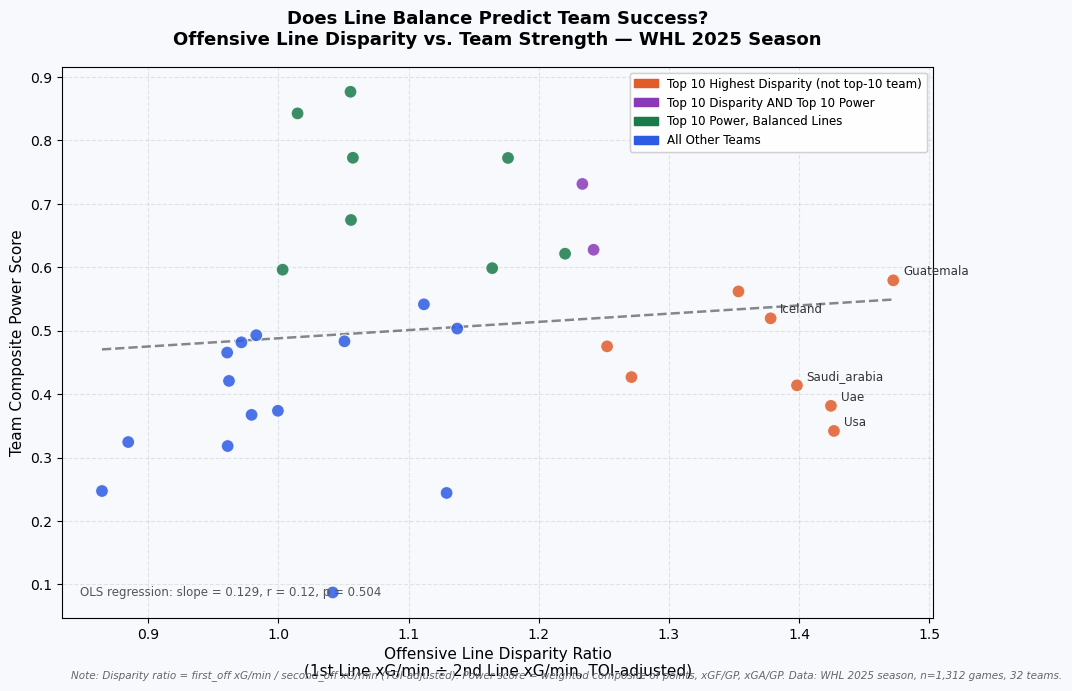

In [7]:
# ============================================================
# PHASE 1c — Data Visualization
# IMPORTANT: Change TEAM_NAME to your team name (no spaces)
# Needs: avg_lines (from 1b) and league_table (from 1a)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

TEAM_NAME = 'BrooklineFintechFishes'   # <-- CHANGE THIS before running

# Merge disparity data with power score
viz = avg_lines.merge(league_table[['team','power_score','PTS','power_rank']], on='team')

# Define groups for color coding
top10_disparity = avg_lines.head(10)['team'].values
top10_power     = league_table.head(10)['team'].values

def get_color(team):
    if team in top10_disparity and team in top10_power:
        return '#8a3ab9'  # purple: high disparity AND strong team
    elif team in top10_disparity:
        return '#e05c2b'  # orange: high disparity, not top-10 team
    elif team in top10_power:
        return '#1a7a4a'  # green: top-10 team, balanced lines
    else:
        return '#2d5be3'  # blue: all other teams

colors = [get_color(t) for t in viz['team']]

# ── PLOT ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#f7f9fc')
ax.set_facecolor('#f7f9fc')

ax.scatter(viz['disparity_ratio'], viz['power_score'],
           c=colors, s=85, alpha=0.85,
           edgecolors='white', linewidth=0.8, zorder=3)

# Linear regression line (OLS)
slope, intercept, r, p, se = stats.linregress(
    viz['disparity_ratio'], viz['power_score'])
x_line = np.linspace(viz['disparity_ratio'].min(),
                     viz['disparity_ratio'].max(), 100)
ax.plot(x_line, slope * x_line + intercept,
        '--', color='#555', linewidth=1.8, alpha=0.7,
        label=f'Regression line (r = {r:.2f}, p = {p:.3f})')

# Label top 5 disparity teams
for _, row in viz.iterrows():
    if row['team'] in avg_lines.head(5)['team'].values:
        ax.annotate(row['team'].capitalize(),
                    (row['disparity_ratio'], row['power_score']),
                    textcoords='offset points', xytext=(7, 4),
                    fontsize=8.5, color='#333')

# Axis labels and title
ax.set_xlabel(
    'Offensive Line Disparity Ratio\n'
    '(1st Line xG/min ÷ 2nd Line xG/min, TOI-adjusted)',
    fontsize=11)
ax.set_ylabel('Team Composite Power Score', fontsize=11)
ax.set_title(
    'Does Line Balance Predict Team Success?\n'
    'Offensive Line Disparity vs. Team Strength — WHL 2025 Season',
    fontsize=13, fontweight='bold', pad=16)
ax.grid(True, alpha=0.3, linestyle='--')

# Legend
handles = [
    mpatches.Patch(color='#e05c2b', label='Top 10 Highest Disparity (not top-10 team)'),
    mpatches.Patch(color='#8a3ab9', label='Top 10 Disparity AND Top 10 Power'),
    mpatches.Patch(color='#1a7a4a', label='Top 10 Power, Balanced Lines'),
    mpatches.Patch(color='#2d5be3', label='All Other Teams'),
]
ax.legend(handles=handles, fontsize=8.5, loc='upper right')
ax.add_artist(ax.get_legend())

# Add regression stats as subtitle annotation
ax.text(0.02, 0.04,
    f'OLS regression: slope = {slope:.3f}, r = {r:.2f}, p = {p:.3f}',
    transform=ax.transAxes, fontsize=8.5, color='#555')

# Data caption
ax.text(0.01, -0.11,
    'Note: Disparity ratio = first_off xG/min / second_off xG/min (TOI-adjusted).'
    ' Power score = weighted composite of points, xGF/GP, xGA/GP.'
    ' Data: WHL 2025 season, n=1,312 games, 32 teams.',
    transform=ax.transAxes, fontsize=7.5, color='#666', style='italic')

plt.tight_layout()
filename = f'{TEAM_NAME}.png'
plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#f7f9fc')
print(f'Saved: {filename}')
plt.show()


**PHASE 1d — Tell Your Story (Methodology Write-up)**

**PROCESS**

**Data cleaning/transformation (~50 words):**

ANSWER HERE

**Additional variables created (~25 words):**

ANSWER HERE

**TOOLS AND TECHNIQUES**

**Software tools used:**

ANSWER HERE

**How tools were used (~50 words):**

ANSWER HERE

**Statistical methods (~100 words):**

ANSWER HERE

**YOUR PREDICTIONS**

**1a — Power rankings and win probabilities (~50 words):**

ANSWER HERE

**1b — Offensive line quality disparity (~50 words):**

ANSWER HERE

**1c — Visualization choices (~50 words):**

ANSWER HERE

**YOUR INSIGHTS**

**Model performance assessment (~50 words):**

ANSWER HERE

**Generative AI usage (~50 words):**

ANSWER HERE

